# 1 — Getting started with seqcraft

seqcraft has **three concepts**, and this notebook uses all of them in the first ten cells.

| Concept | What it is |
|---|---|
| `LogicBlock` | a tree of pulseq events, each with a start time. Two attributes, one method. |
| `Module` | a reusable sequence task. `__init__` designs, `build()` returns a logic block. |
| `sc.compile` | turns the tree into legal pulseq blocks. |

Everything overlaps freely in the tree. Making it legal for pulseq is the compiler's job — which
is what lets you say *what you mean* and never think about block boundaries.

In [1]:
%matplotlib inline

import math

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

print('seqcraft', sc.__version__)
print('pypulseq', sc._compat.PYPULSEQ_VERSION)

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


seqcraft 0.3.0
pypulseq 1.5.1


## 1. The scanner

A `System` holds one or more **named limit regimes**. Real sequences need more than one: a
diffusion encoding may run at full amplitude while the readout is derated for peripheral nerve
stimulation. Those are two regimes of one system, and seqcraft checks that they agree on the
rasters — nothing upstream does, and a disagreement produces a file the scanner rejects.

In [2]:
system = sc.System.preset('generic_3t').derate('quiet', grad=0.7, slew=0.4)
print(system.describe())

System 'generic 3T'  B0 = 3 T  gamma = 4.2576e+07 Hz/T
  default    max_grad =   40.00 mT/m   max_slew =  150.00 T/m/s
  quiet      max_grad =   28.00 mT/m   max_slew =   60.00 T/m/s
  rasters    grad 10 us   rf 1 us   adc 100 ns   block 10 us


## 2. A logic block is a list of `(start, event)` pairs

That is the entire data model. `add` takes several events at one time, exactly like pulseq's
`add_block`, and returns the same block so calls can chain.

In [3]:
o = system.default
rf, gz, gzr = pp.make_sinc_pulse(
    flip_angle=math.radians(15), duration=1e-3, slice_thickness=5e-3,
    apodization=0.5, time_bw_product=4, system=o, return_gz=True, use='excitation',
)

lb = sc.LogicBlock('excitation')
lb.add(0.0, rf, gz)                       # the pulse and its slice-select gradient
lb.add(pp.calc_duration(rf, gz), gzr)     # then the rephaser
lb

C:\Users\bughh\AppData\Local\Temp\ipykernel_44308\2824037332.py:2: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf, gz, gzr = pp.make_sinc_pulse(


LogicBlock(excitation, 3 nodes, 1.80 ms)

`duration` is **measured**, never declared — a block cannot advertise a length that disagrees with
what it plays. And CRUD is Python's, not seqcraft's:

In [4]:
print(f'duration        {lb.duration * 1e6:.0f} us')
print(f'read   nodes[1] {lb.nodes[1].item.type} on {lb.nodes[1].item.channel}')

lb.nodes[2].start += 100e-6               # update
print(f'update          {lb.duration * 1e6:.0f} us after nudging the rephaser')
lb.nodes[2].start -= 100e-6

removed = lb.nodes.pop()                  # delete
print(f'delete          {lb!r}')
lb.add(pp.calc_duration(rf, gz), gzr)     # put it back

duration        1800 us
read   nodes[1] trap on z
update          1900 us after nudging the rephaser
delete          LogicBlock(excitation, 2 nodes, 1.26 ms)


LogicBlock(excitation, 3 nodes, 1.80 ms)

### Blocks nest, and the tree *is* the provenance

`sc.flatten` walks the tree, summing start times and collecting the chain of tags. Nothing needs
to keep track of where anything came from.

In [5]:
inner = sc.LogicBlock('spoiler').add(0.0, pp.make_trapezoid('z', area=800.0, system=o))
outer = sc.LogicBlock('tr').add(0.0, lb).add(5e-3, inner)

for start, event, path in sc.flatten(outer):
    print(f'  t = {start * 1e6:7.1f} us   {event.type:5}   {".".join(path)}')

print()
print(outer.describe())

  t =     0.0 us   rf      tr.excitation
  t =     0.0 us   trap    tr.excitation
  t =  1260.0 us   trap    tr.excitation
  t =  5000.0 us   trap    tr.spoiler

tr  5.74 ms
  +0.0 us  excitation  1.80 ms
    +0.0 us  rf
    +0.0 us  trap z
    +1260.0 us  trap z
  +5000.0 us  spoiler  0.74 ms
    +0.0 us  trap z


## 3. Modules build reusable logic blocks

A module works like `torch.nn.Module`: the expensive design happens once in `__init__`, and
`build()` is cheap. **Timing a caller needs in order to place the block is a property of the
module**, because the module is the thing with the domain knowledge — a block cannot know where it
sits, and pinning the answer into it would stop the same block being reused elsewhere.

In [6]:
exc = sc.modules.SincExcitation(
    system, flip_deg=15, duration_us=1000, slice_thickness_mm=5, rephase=False)
ro = sc.modules.CartesianLine(
    system, fov_ro_mm=250, matrix_ro=64, readout_duration_us=3200, prephase=False)
pe = sc.modules.PhaseEncode(system, fov_pe_mm=250, matrix_pe=64)
spoil = sc.modules.Spoiler(system, twists=4, voxel_mm=5)

print(f'exc.isodelay        {exc.isodelay * 1e6:7.1f} us   <- TE is measured from here')
print(f'exc.pulse_duration  {exc.pulse_duration * 1e6:7.1f} us')
print(f'exc.bandwidth_hz    {exc.bandwidth_hz:7.0f} Hz')
print(f'exc.peak_b1_uT      {exc.peak_b1_uT:7.2f} uT')
print()
print(f'ro.time_to_echo     {ro.time_to_echo * 1e6:7.1f} us   <- the readout is placed by this')
print(f'ro.k_max_per_m      {ro.k_max_per_m:7.1f} 1/m  = matrix / (2 FOV)')
print(f'ro.bandwidth/pixel  {ro.bandwidth_per_pixel_hz:7.1f} Hz')
print()
print(f'spoil.area_per_m    {spoil.area_per_m:7.1f} 1/m  = twists / voxel')

exc.isodelay          630.0 us   <- TE is measured from here
exc.pulse_duration   1260.0 us
exc.bandwidth_hz       4000 Hz
exc.peak_b1_uT         3.87 uT

ro.time_to_echo      1620.0 us   <- the readout is placed by this
ro.k_max_per_m        128.0 1/m  = matrix / (2 FOV)
ro.bandwidth/pixel    312.5 Hz

spoil.area_per_m      800.0 1/m  = twists / voxel


e:\MGH\SeqCraft\src\seqcraft\modules\rf\pulses.py:522: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf, gz, gzr = pp.make_sinc_pulse(


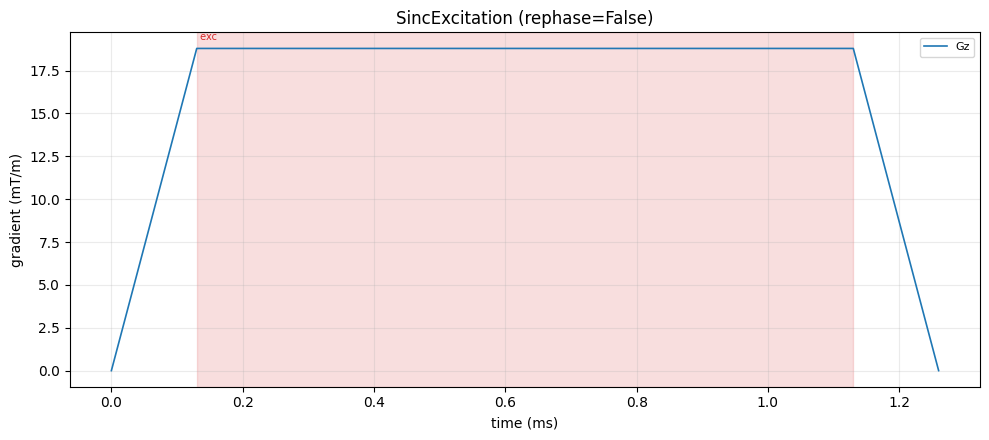

In [7]:
figure = sc.plot_block(exc.build(), system, title='SincExcitation (rephase=False)')
plt.show()

## 4. Crafting a sequence: overlap is free

Here is the case that motivated the whole design. In a gradient echo the **slice rephaser (z)**,
the **phase-encode blip (y)** and the **readout prephaser (x)** all want the same slot. In
seqcraft you place all three at the same time and stop thinking about it — they are on different
axes, so the compiler puts them in one block and says nothing, because there is nothing wrong.

And `t0 + te - ro.time_to_echo` **is** the definition of TE. No gap solver, no constraint
language, nothing hidden.

In [8]:
te, tr = 8e-3, 20e-3
seq = sc.LogicBlock('gre_demo')

for i, line in enumerate(range(-32, 32)):
    t0 = i * tr
    t_winders = t0 + exc.pulse_duration
    t_readout = t0 + te - ro.time_to_echo          # <- this defines TE

    seq.add(t0, exc.build(rf_phase_rad=sc.rf_spoil_phase(i)))
    seq.add(t_winders, exc.rephaser())             # z
    seq.add(t_winders, pe.build(line=line))        # y   } one block,
    seq.add(t_winders, ro.prephaser_block())       # x   } no coordination
    seq.add(t_readout, ro.build())
    seq.add(t_readout + ro.duration, spoil.build())
    seq.add(t_readout, pp.make_label('LIN', 'SET', line + 32))

seq

LogicBlock(gre_demo, 448 nodes, 1270.36 ms)

In [9]:
geometry = sc.Geometry(fov_mm=(250, 250, 5), matrix=(64, 64, 1), slice_thickness_mm=5)
out = sc.compile(seq, system, geometry=geometry, name='gre_demo',
                 definitions={'TE': te, 'TR': tr})
report = out.check()
print(out)
print('check ok:', report.ok)
print(f'blocks per TR: {out.n_blocks / 64:.1f}')

CompiledSequence(gre_demo, 383 blocks, 1.270 s, 0 errors, 64 warnings)
check ok: True
blocks per TR: 6.0


The three winders really did land in one block. `origin` traces a block back to what produced it,
and where several modules share a block it reports their **common ancestor** rather than picking
one arbitrarily — which is the honest answer to "where did this come from".

In [10]:
for index in range(6):
    block = out.seq.get_block(index + 1)
    axes = ''.join(a for a in 'xyz' if getattr(block, f'g{a}', None) is not None) or '-'
    kinds = ' '.join(
        name for name, present in
        (('rf', getattr(block, 'rf', None) is not None),
         ('adc', getattr(block, 'adc', None) is not None))
        if present
    )
    print(f'  block {index}: {out.seq.block_durations[index + 1] * 1e6:7.1f} us  '
          f'grad[{axes:3}] {kinds:7} from {".".join(out.origin(index)) or "-"}')

  block 0:  1260.0 us  grad[z  ] rf      from gre_demo.exc
  block 1:   540.0 us  grad[xyz]         from gre_demo
  block 2:  4580.0 us  grad[-  ]         from -
  block 3:  3240.0 us  grad[x  ] adc     from gre_demo
  block 4:   740.0 us  grad[z  ]         from gre_demo.spoil
  block 5:  9640.0 us  grad[-  ]         from -


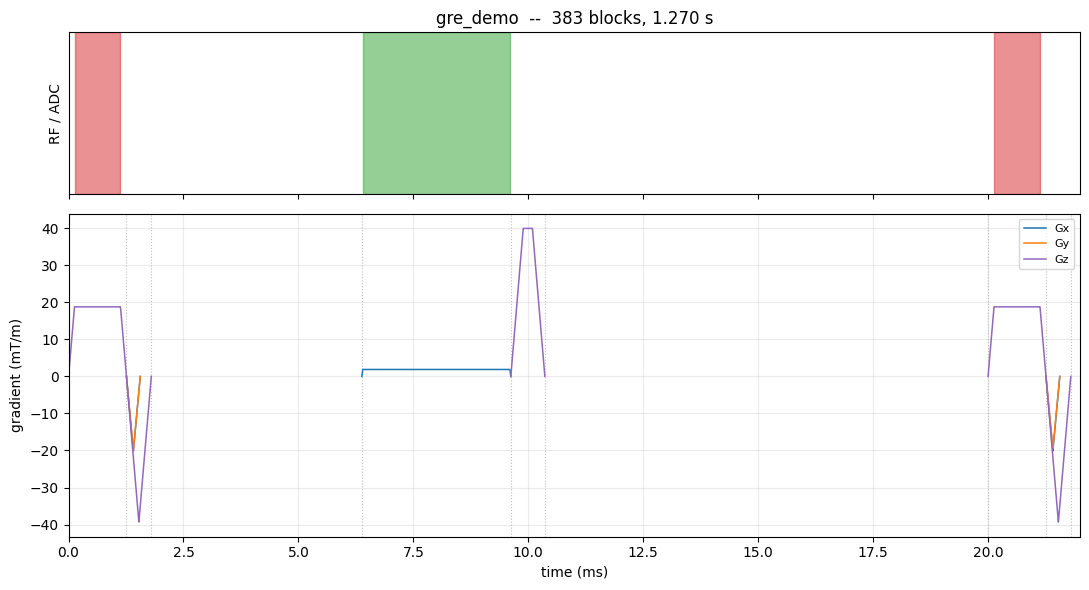

In [11]:
figure = sc.plot_sequence(out, time_range=(0.0, 22e-3))
plt.show()

Verify the physics rather than trusting it. The echo should land exactly at TE, and k-space should
span `matrix / (2 FOV)`:

In [12]:
k = out.kspace()
n = ro.n_samples
window = k['t_adc'][:n]
centre = 0.5 * (window[n // 2 - 1] + window[n // 2])       # no sample sits exactly at k=0
print(f'echo at         {(centre - k["t_excitation"][0]) * 1e6:.1f} us   (TE = {te * 1e6:.0f} us)')
print(f'k_x extent      {np.abs(k["k_adc"][0]).max():.1f} 1/m   (k_max = {ro.k_max_per_m:.1f})')
print(f'k_y extent      {np.abs(k["k_adc"][1]).max():.1f} 1/m   (32 lines x {pe.dk_per_m:.1f})')
print(f'dk_y            {pe.dk_per_m:.2f} 1/m   = 1/FOV = {1e3 / 250:.2f}')

echo at         7370.0 us   (TE = 8000 us)
k_x extent      126.0 1/m   (k_max = 128.0)
k_y extent      128.0 1/m   (32 lines x 4.0)
dk_y            4.00 1/m   = 1/FOV = 4.00


With an even sample count there is **no sample exactly at k=0** — the two central ones straddle it
by half a dwell. That is why the echo is measured at the centre of the ADC *window*, and why the
k_x extent comes out slightly under `k_max`.

## 5. The compiler's three rules on overlap

Each was chosen deliberately, and the reasoning explains what the warnings mean.

In [13]:
def try_it(label, build):
    lb = sc.LogicBlock('demo')
    build(lb)
    try:
        result = sc.compile(lb, system)
    except sc.CompileError as err:
        print(f'{label:32} ERROR: {str(err).splitlines()[0]}')
        return
    merges = len(result.report.of_kind('grad_merge'))
    errors = len(result.report.errors)
    warns = len(result.report.warnings)
    print(f'{label:32} {result.n_blocks} block(s), {merges} merge, '
          f'{errors} error, {warns} warning')


gentle = {'area': 100.0, 'duration': 2e-3, 'rise_time': 200e-6, 'system': o}

try_it('different axes at once', lambda lb: lb
       .add(0.0, pp.make_trapezoid('x', **gentle))
       .add(0.0, pp.make_trapezoid('y', **gentle))
       .add(0.0, pp.make_trapezoid('z', **gentle)))

try_it('same axis at once', lambda lb: lb
       .add(0.0, pp.make_trapezoid('x', area=100.0, system=o))
       .add(0.0, pp.make_trapezoid('x', area=200.0, system=o)))

rf2 = pp.make_sinc_pulse(flip_angle=1.57, duration=1e-3, system=o, use='excitation')
try_it('two RF pulses overlapping', lambda lb: lb.add(0.0, rf2).add(0.5e-3, rf2))

adc2 = pp.make_adc(num_samples=64, dwell=10e-6, system=o)
try_it('transmit while receiving', lambda lb: lb.add(0.0, adc2).add(0.3e-3, rf2))

different axes at once           1 block(s), 0 merge, 0 error, 0 warning
same axis at once                1 block(s), 1 merge, 1 error, 1 warning


two RF pulses overlapping        ERROR: RF and RF overlap by 630.0 us -- the transmitter cannot play two pulses at once.
transmit while receiving         ERROR: ADC and RF overlap by 360.0 us -- the coil cannot transmit and receive at the same time.


C:\Users\bughh\AppData\Local\Temp\ipykernel_44308\1930887044.py:27: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf2 = pp.make_sinc_pulse(flip_angle=1.57, duration=1e-3, system=o, use='excitation')
C:\Users\bughh\AppData\Local\Temp\ipykernel_44308\1930887044.py:27: UserWarning: system maximum RF amplitude exceeded (130.0%)
  rf2 = pp.make_sinc_pulse(flip_angle=1.57, duration=1e-3, system=o, use='excitation')


- **Different axes: silent.** A phase encode beside a rephaser beside a prephaser is the normal way
  to build a sequence. Warning about it would only teach you to ignore warnings.
- **Same axis: warned, then summed.** Summing is almost always what you meant, so it happens — but
  it is the one place the compiler changes a waveform, so it says so.
- **Two RF or two ADC: an error.** You cannot transmit twice at once, sample twice at once, or
  transmit and receive at once. No choice of block boundaries fixes that, so compilation stops.

### Limits are checked *after* summing

This is the part that cannot be done anywhere else.

In [14]:
lb = sc.LogicBlock('collision')
lb.add(0.0, pp.make_trapezoid('x', area=100.0, system=o))
lb.add(0.0, pp.make_trapezoid('x', area=200.0, system=o))
result = sc.compile(lb, system)

for issue in result.report.issues:
    print(f'[{issue.severity:7}] {issue.kind:16} {issue.message}')

[warning] grad_merge       2 gradients overlap on axis x over 0.0..360.0 us and were summed: collision
[error  ] slew_limit       slew on x reaches 284.0 T/m/s, limit 150.0 T/m/s (189%); from collision


Each of those trapezoids is legal on its own. Together they reach **189 % of the slew limit** — and
no module could have seen that, because neither one is doing anything wrong. That is why the
compiler measures the compiled waveform instead of trusting the modules that produced it.

The vector norm across axes is a *warning*, not an error: two axes ramping together reach √2 times
the per-axis slew in vector magnitude, which real amplifiers permit.

### The error messages name what to change

In [15]:
try:
    sc.modules.SincExcitation(system, flip_deg=180, duration_us=500,
                              slice_thickness_mm=5, rephase=False)
except sc.ConfigurationError as err:
    print(err)

a 180 degree pulse in 500 us needs at least 23.5 uT, above the 20.0 uT limit.
  flip_deg   :  180.0
  duration_us:  500.0
  max_b1_uT  :  20.0
  fix
    lengthen the pulse to at least 587 us (a shaped pulse needs roughly twice that)
    reduce flip_deg
    use an adiabatic pulse, which reaches a full inversion at lower peak B1


That is real physics, not a bug: a 180° pulse in 500 µs needs about 23 µT. pypulseq's own message
is `Amplitude violation (117%)`, which does not say which of the three parameters to change.

## 6. Escape hatches

Two, both first-class. `sc.barrier()` forces a block boundary where the compiler would not have put
one, and `RawEvents` wraps arbitrary pypulseq events as a module — so nothing forces you to wait
for a module to be written.

In [16]:
long_g = pp.make_trapezoid('x', area=2000.0, duration=4e-3, system=o)

plain = sc.compile(sc.LogicBlock('t').add(0.0, long_g), system)
split = sc.compile(sc.LogicBlock('t').add(0.0, long_g).add(2e-3, sc.barrier('mid')), system)
print(f'without barrier: {plain.n_blocks} block,  m0 = {plain.moments()["x"]:.3f} 1/m')
print(f'with barrier:    {split.n_blocks} blocks, m0 = {split.moments()["x"]:.3f} 1/m  '
      f'(area preserved, halves join)')

raw = sc.modules.RawEvents(system, events=(long_g,), tag='hand_built')
print(f'\nRawEvents: {raw.build()!r}')

without barrier: 1 block,  m0 = 2000.000 1/m
with barrier:    2 blocks, m0 = 2000.000 1/m  (area preserved, halves join)

RawEvents: LogicBlock(hand_built, 1 node, 4.00 ms)


## 7. Writing the file

`write` takes **no** geometry, matrix or FOV arguments. Everything written comes from what was
compiled, so the file's metadata cannot disagree with what it plays. A JSON sidecar records the
package versions, the git state, the definitions and the file's sha256.

In [17]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmp:
    written = out.write(Path(tmp) / 'gre_demo.seq')
    print(f'{written.path.name}  {written.path.stat().st_size / 1e3:.1f} kB')
    print(f'sha256  {written.sha256[:16]}...')
    print(f'sidecar {written.sidecar.name}')

    again = pp.Sequence(system=system.default)
    again.read(str(written.path))
    print(f'\nread back: {len(again.block_events)} blocks, {again.duration()[0]:.4f} s')

gre_demo.seq  32.4 kB
sha256  a88b09d2f8872d9c...
sidecar gre_demo.seq.json

read back: 383 blocks, 1.2704 s


## 8. A whole multislice sequence

Everything above, assembled: a spoiled 2D gradient echo over three slices. There is no recipe to
call, deliberately — a recipe is somebody else's sequence choices in library code, so changing your
scan would mean editing a package, and the package would accumulate everyone's variants. What
replaces it is the loop below. The placement *is* the sequence, and it is short enough to read in one
go.

The three winders — slice rephaser on z, phase blip on y, readout prephaser on x — are added at one
time on three axes. That is the overlap section 4's rule exists to make free, and here it is doing
the work in a real sequence.

Two details worth pointing at, because both are easy to get wrong and neither announces itself:

**`PhaseEncode(line=...)` is a signed index from the centre of k-space**, not a counter from zero.
`Geometry` supplies the acquisition order and the centre line, so the signed value is
`line - geometry.kspace_center_line`. Passing the raw counter doubles the largest blip — which on
this system asks 175 % of the slew limit, so the compiler catches it. It would not catch a
*half*-sized one.

**`rf_spoil_phase` is a closed form**, `inc * n(n+1)/2 mod 2pi`, not a running accumulator that
drifts. On a real scan the receiver phase has to track the transmit phase shot by shot;
`CartesianLine` does not expose that yet, so this sequence spoils the transmit side only.

CompiledSequence(gre_2d, 1151 blocks, 3.831 s, 0 errors, 192 warnings)
3 slices x 64 lines = 192 shots, 3.83 s
TE requested 8.00 ms, k=0 crossed at 8.025 ms
warnings: {'slew_norm_limit': 192}
  Three winders on three axes at one instant: each is inside its own per-axis limit, and the
  vector norm across them is not.  Real amplifiers permit up to sqrt(3) times the per-axis
  slew on three axes, so this is a warning rather than an error -- see docs/compiler.md.


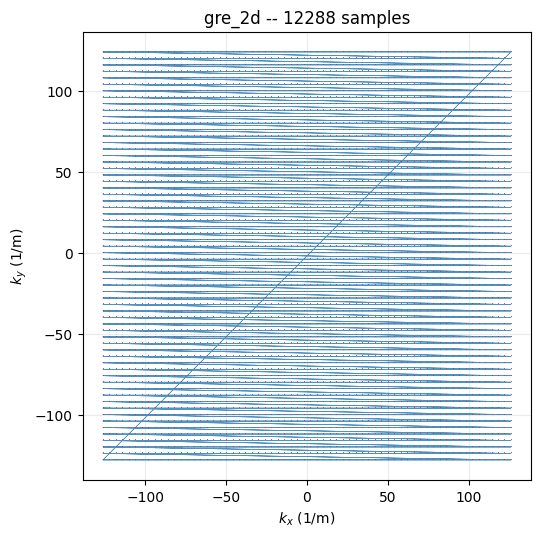

In [18]:
FOV_MM, MATRIX, SLICE_MM, N_SLICES = 250.0, 64, 5.0, 3
TE, TR, FLIP_DEG, SPOIL_DEG = 8e-3, 20e-3, 15.0, 117.0

geometry = sc.Geometry(
    fov_mm=(FOV_MM, FOV_MM, SLICE_MM), matrix=(MATRIX, MATRIX, 1),
    slice_thickness_mm=SLICE_MM, n_slices=N_SLICES,
)
# rephase=False and prephase=False so all three winders can be placed together, below.
excitation = sc.modules.SincExcitation(
    system, flip_deg=FLIP_DEG, duration_us=1000, slice_thickness_mm=SLICE_MM, rephase=False)
readout = sc.modules.CartesianLine(
    system, fov_ro_mm=FOV_MM, matrix_ro=MATRIX, readout_duration_us=3200, prephase=False)
encode = sc.modules.PhaseEncode(system, fov_pe_mm=FOV_MM, matrix_pe=MATRIX)
spoil = sc.modules.Spoiler(system, twists=4, voxel_mm=SLICE_MM)

raster = system.block_raster_s
t_winders = sc.raster.ceil_to(excitation.duration, raster)
t_readout = sc.raster.ceil_to(excitation.isodelay + TE - readout.time_to_echo, raster)
t_spoil = sc.raster.ceil_to(t_readout + readout.duration, raster)
tr = sc.raster.ceil_to(TR, raster)
if tr < t_spoil + spoil.duration:
    raise ValueError(
        f'TR {TR * 1e3:.1f} ms cannot hold a {(t_spoil + spoil.duration) * 1e3:.2f} ms shot')

gre = sc.LogicBlock('gre_2d')
shot = 0
for slice_index in sc.interleaved_slice_order(N_SLICES):
    z = geometry.slice_positions_m[slice_index]
    for line in geometry.pe_lines:
        t0 = shot * tr
        phase = sc.rf_spoil_phase(shot, math.radians(SPOIL_DEG))
        gre.add(t0, excitation.build(slice_offset_m=z, rf_phase_rad=phase))
        # Three winders, one instant, three axes -- and the compiler says nothing, which is the point.
        gre.add(t0 + t_winders, excitation.rephaser())
        gre.add(t0 + t_winders, encode.build(line=line - geometry.kspace_center_line))
        gre.add(t0 + t_winders, readout.prephaser_block())
        gre.add(t0 + t_readout, readout.build())
        gre.add(t0 + t_spoil, spoil.build())
        gre.add(t0 + t_readout,
                pp.make_label('LIN', 'SET', line),
                pp.make_label('SLC', 'SET', slice_index))
        shot += 1

gre = sc.compile(gre, system, geometry=geometry, name='gre_2d',
                 definitions={'TE': TE, 'TR': tr, 'FlipAngle': FLIP_DEG,
                              'RfSpoilIncrementDeg': SPOIL_DEG, **readout.definitions()})
gre.check().raise_if_failed()
print(gre)
print(f'{N_SLICES} slices x {MATRIX} lines = {shot} shots, {gre.duration_s:.2f} s')

# The echo really is at TE.  Search inside the *first shot* only: k_adc runs over every sample in
# the sequence, so a global argmin lands in whichever of the 192 shots happened to pass closest to
# the origin -- 3828 ms into the scan, which looks like a catastrophic timing bug and is really just
# the wrong question.
k = gre.kspace()
first_shot = slice(0, readout.n_samples)
echo = int(np.argmin(np.abs(k['k_adc'][0][first_shot])))
print(f"TE requested {TE * 1e3:.2f} ms, k=0 crossed at "
      f"{(k['t_adc'][echo] - k['t_excitation'][0]) * 1e3:.3f} ms")

# 192 warnings, one per shot, and they are the expected ones -- worth naming rather than ignoring.
from collections import Counter
print('warnings:', dict(Counter(issue.kind for issue in gre.report.warnings)))
print('  Three winders on three axes at one instant: each is inside its own per-axis limit, and the')
print('  vector norm across them is not.  Real amplifiers permit up to sqrt(3) times the per-axis')
print('  slew on three axes, so this is a warning rather than an error -- see docs/compiler.md.')

figure = sc.plot_kspace(gre)
plt.show()

## What to read next

- **`02_dti_spiral.ipynb`** — a spin-echo spiral DTI sequence end to end, with the b-value verified
  against numerical integration and the trajectory checked against Nyquist.
- **`docs/writing_a_module.md`** — how to write your own module. It is one class with an `__init__`
  and a `build`.
- **`docs/compiler.md`** — how the compiler chooses block boundaries, for when you want to know why
  a particular block appeared.